# Webinar 1 — Fundamentos de Series Temporales
**Dataset:** PJM Hourly Energy Consumption  
**Descarga:** https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Cargar y preparar el dataset

In [6]:
df = pd.read_csv("AEP_hourly.csv", index_col=0, parse_dates=True)
df = df.sort_index()
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [7]:
df.index.is_monotonic_increasing

True

<Axes: title={'center': 'Consumo eléctrico — primer trimestre 2017'}, xlabel='Datetime'>

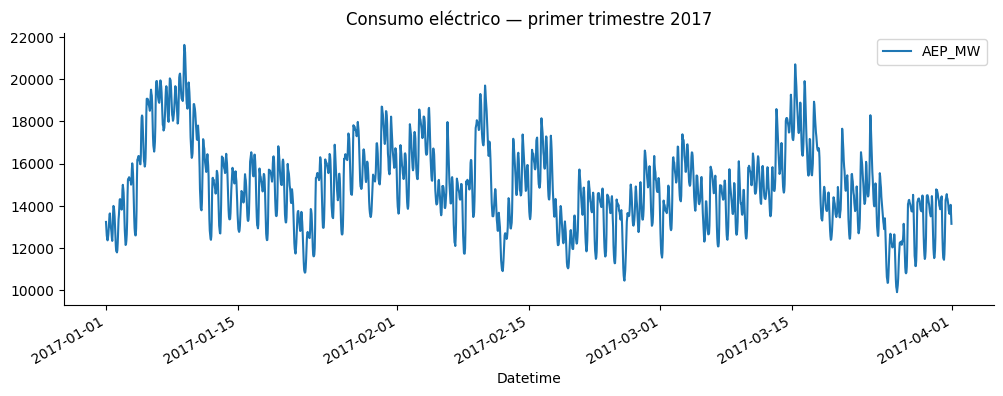

In [8]:
# Selección por fecha
df["2017-01":"2017-03"].plot(title="Consumo eléctrico — primer trimestre 2017")

## 2. Remuestreo

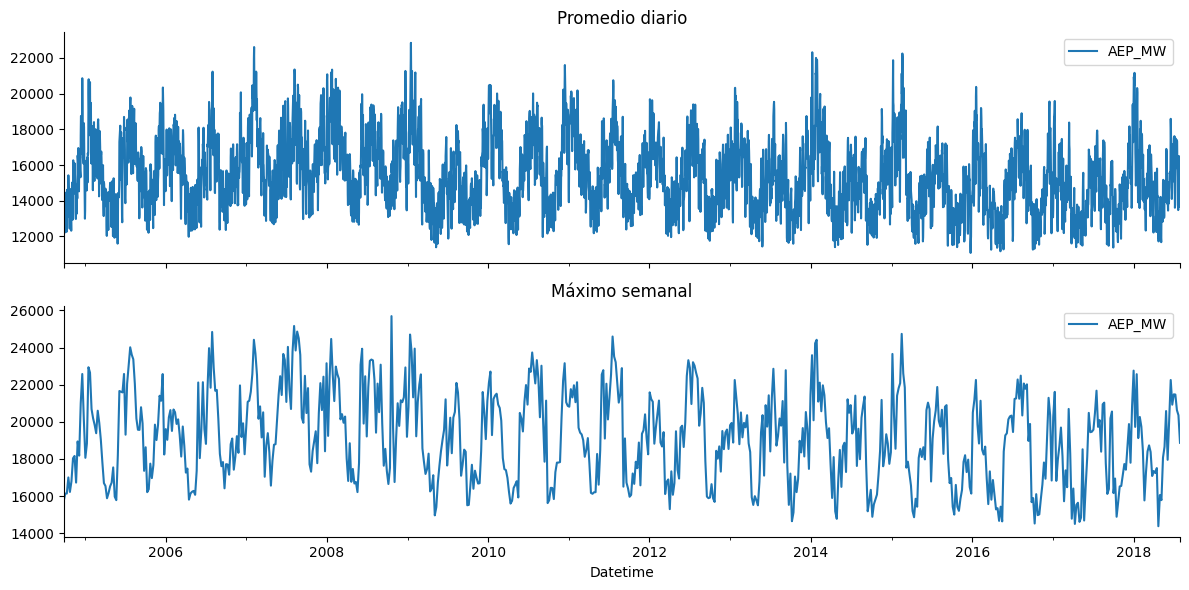

In [9]:
daily  = df.resample("D").mean()
weekly = df.resample("W").max()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily.plot(ax=axes[0], title="Promedio diario")
weekly.plot(ax=axes[1], title="Máximo semanal")
plt.tight_layout()

## 3. Media móvil

<Axes: title={'center': 'Media móvil — 24h y 1 semana'}, xlabel='Datetime'>

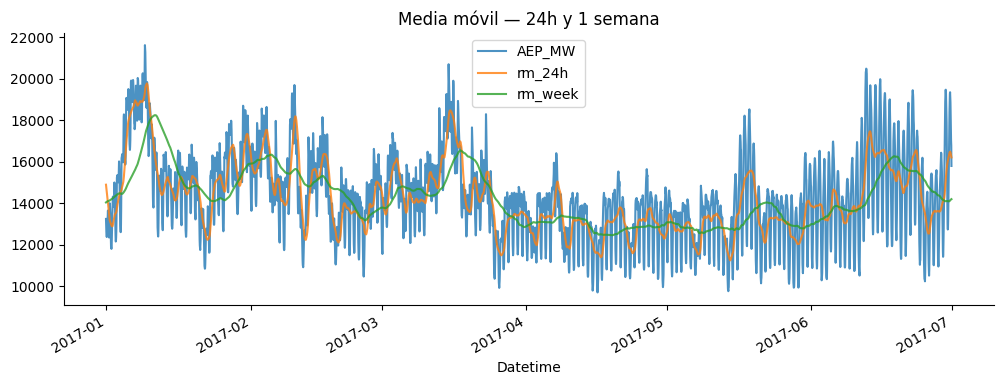

In [10]:
window = df.copy()
window["rm_24h"]  = df["AEP_MW"].rolling(24).mean()
window["rm_week"] = df["AEP_MW"].rolling(168).mean()

window[["AEP_MW", "rm_24h", "rm_week"]] \
    .loc["2017-01":"2017-06"] \
    .plot(title="Media móvil — 24h y 1 semana", alpha=0.8)

## 4. Estacionariedad y diferenciación

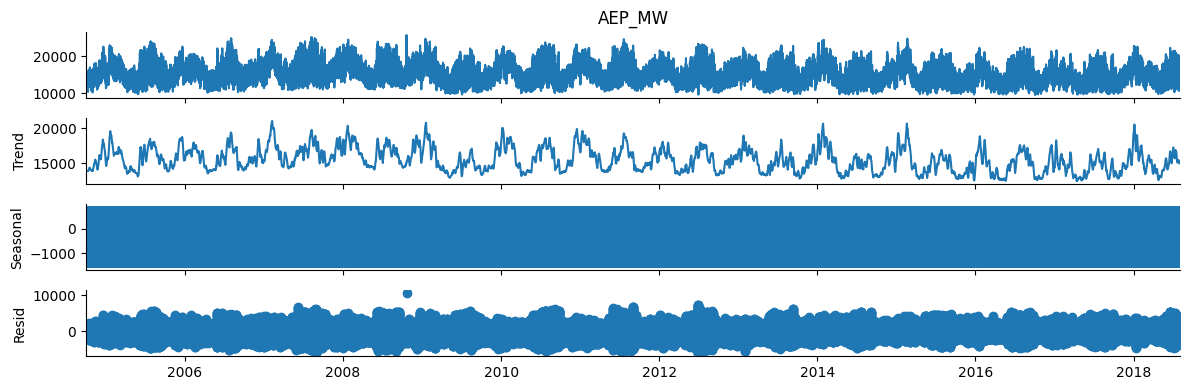

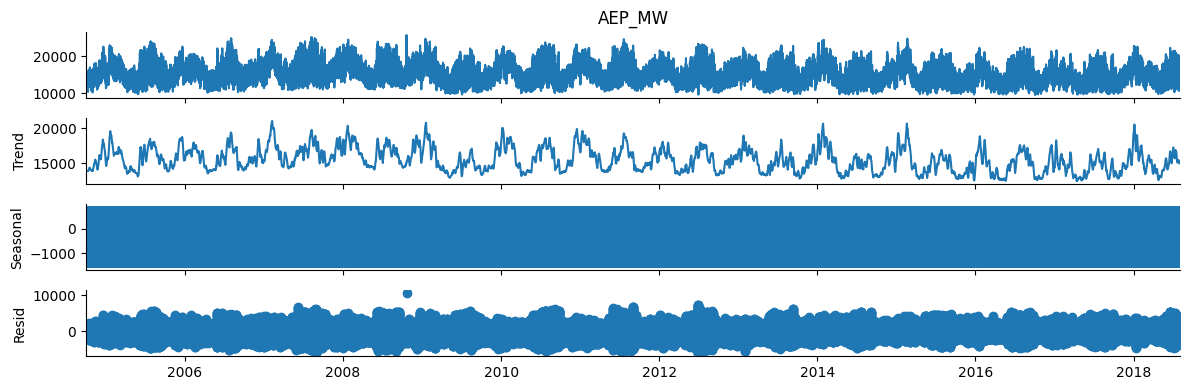

In [15]:
decomposed = seasonal_decompose(df["AEP_MW"], model="additive", period=24*7)
decomposed.plot()


C:\Users\57304\AppData\Local\Temp\ipykernel_30776\1946365708.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  diff = df.resample("w").mean()


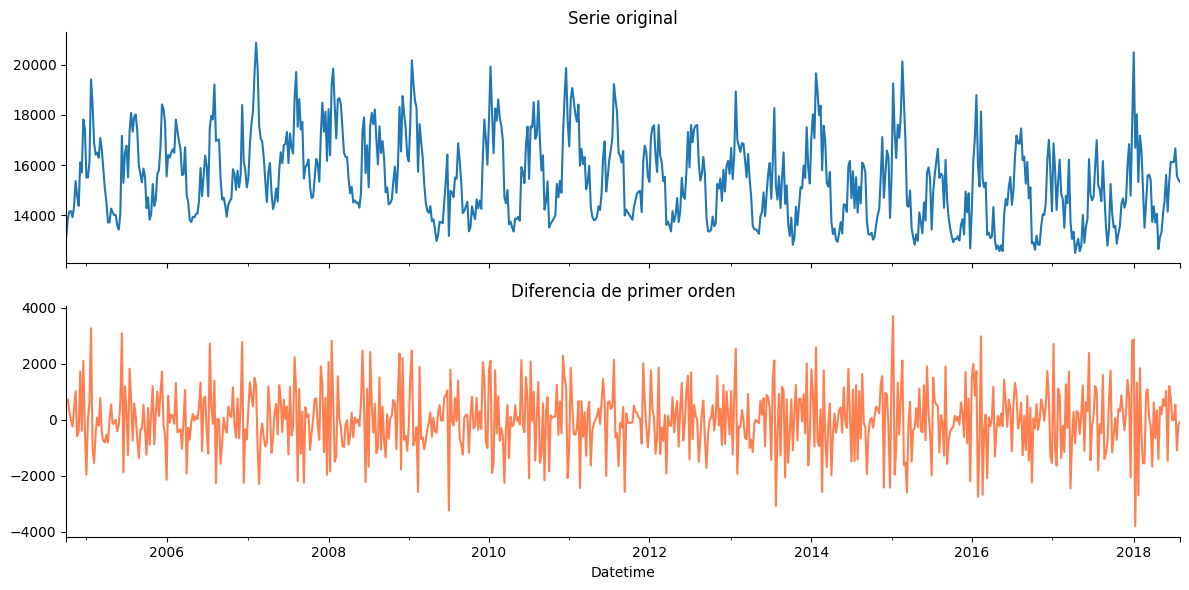

In [17]:
diff = df.resample("w").mean()
diff["diff_1"] = diff["AEP_MW"].diff()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
diff["AEP_MW"].plot(ax=axes[0], title="Serie original")
diff["diff_1"].plot(ax=axes[1], title="Diferencia de primer orden", color="coral")
plt.tight_layout()